In [9]:
#import sys
#!{sys.executable} -m pip install scipy

#import sys
#!{sys.executable} -m pip install matplotlib





In [14]:
import numpy as np
import matplotlib.pyplot as plt
from deltamim_numpy2 import deltamim

delta = [0.22062823 0.38581511 0.16773025]
Si = [0.323333   0.44214746 0.00125388]


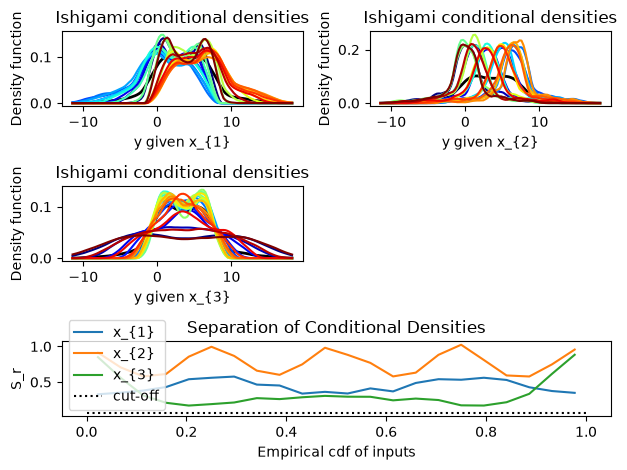

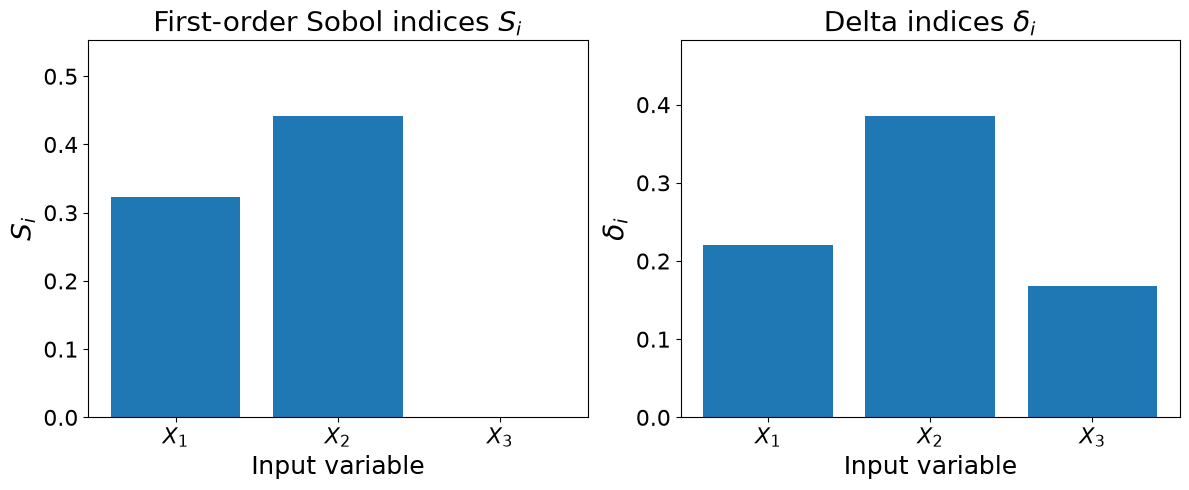

In [16]:


# Reproducibility
rng = np.random.default_rng(123)

# Sample size
N = 10_000

# Generate X1, X2, X3 ~ Uniform[-pi, pi]
X1 = rng.uniform(-np.pi, np.pi, N)
X2 = rng.uniform(-np.pi, np.pi, N)
X3 = rng.uniform(-np.pi, np.pi, N)

# Ishigami parameters
a = 7
b = 0.1

# Ishigami output
y = np.sin(X1) + a * np.sin(X2)**2 + b * X3**4 * np.sin(X1)

# Input matrix
x = np.column_stack([X1, X2, X3])

# Apply deltamim and produce conditional-density plots
delta, Si, acceptL, Seps = deltamim(
    x,
    y,
    gfx="Ishigami conditional densities"
)

print("delta =", delta)
print("Si =", Si)

labels = [r"$X_1$", r"$X_2$", r"$X_3$"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, Si)
axes[0].set_title(r"First-order Sobol indices $S_i$", fontsize=20)
axes[0].set_ylabel(r"$S_i$", fontsize=20)
axes[0].set_xlabel("Input variable", fontsize=18)
axes[0].tick_params(axis="both", labelsize=16)
axes[0].set_ylim(0, max(Si) * 1.25)

axes[1].bar(labels, delta)
axes[1].set_title(r"Delta indices $\delta_i$", fontsize=20)
axes[1].set_ylabel(r"$\delta_i$", fontsize=20)
axes[1].set_xlabel("Input variable", fontsize=18)
axes[1].tick_params(axis="both", labelsize=16)
axes[1].set_ylim(0, max(delta) * 1.25)

plt.tight_layout()
plt.show()